# Test lc_multi_outputs Extension

This notebook tests that the lc_multi_outputs JupyterLab extension is properly installed and enabled.
- Test multi_outputs basic functionality (pin button and output saving)

## Parameters

In [1]:
# Default parameters (will be overridden by Papermill)
notebook7_url = "http://localhost:8888/tree"
jupyter_token = "test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 30000
jupyter_work_dir = '../artifacts/jupyter-work'

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
print(f"Created work directory: {work_dir}")

Created work directory: /var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpp5eyl_re


In [4]:
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

import scripts.notebook7
importlib.reload(scripts.notebook7)

from scripts.playwright import *
from scripts.notebook7 import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251224-154147',
 '/var/folders/tb/rx5f2b6d0jn3g81h4wm1p6b80000gn/T/tmpxp7ociqu')

## Open Jupyter Notebook and wait for it to load

Start epoch: 1766558507.775611 seconds


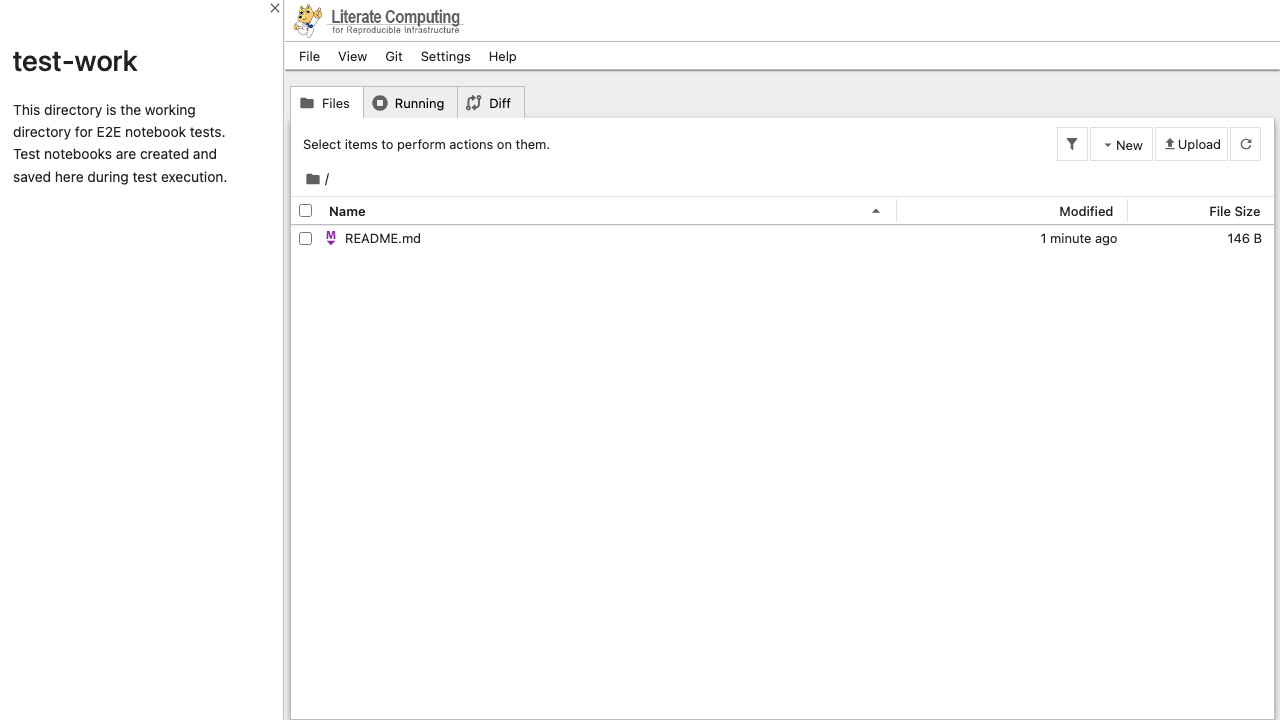

In [5]:
async def _step_wait_for_loading(page):
    await page.goto(f"{notebook7_url}?token={jupyter_token}")

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

await run_pw(_step_wait_for_loading)

## Remove existing test notebook if it exists

Start epoch: 1766558511.947092 seconds
No existing test notebook to remove


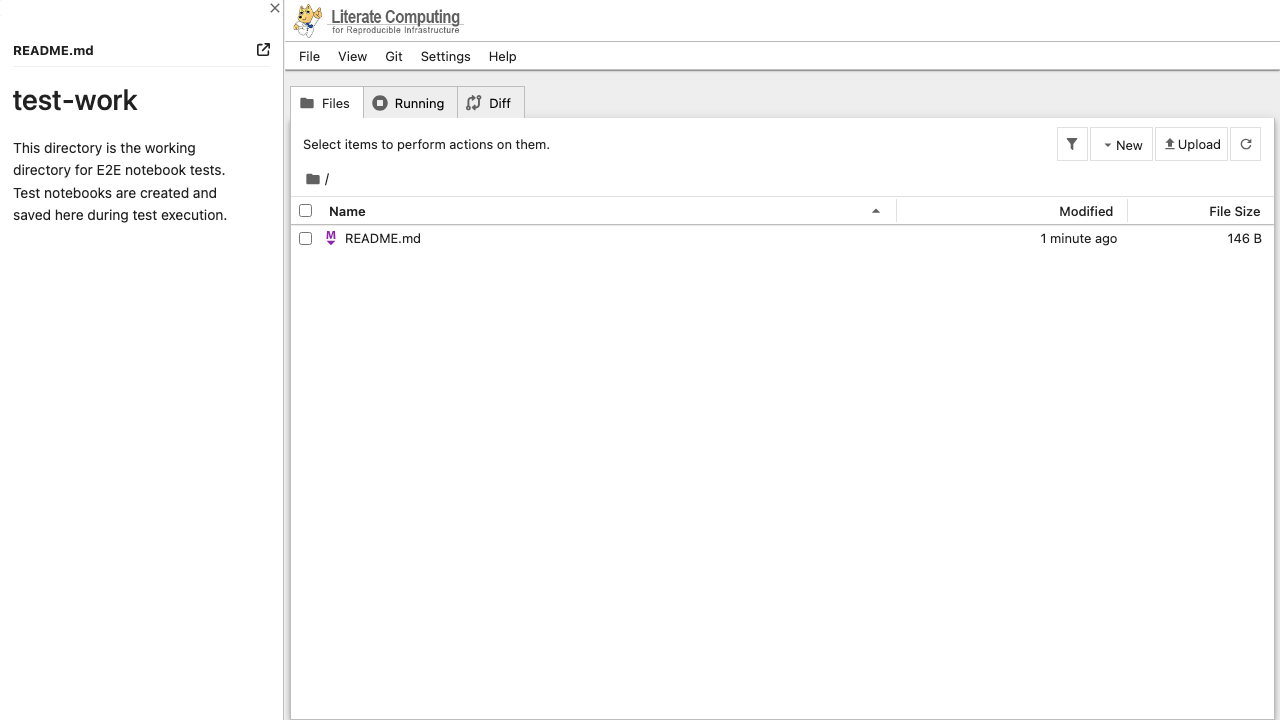

In [6]:
test_filename = "TestMultiOutputsNotebook.ipynb"
async def _step_remove_existing_notebook(page):
    deleted = await delete_file(page, test_filename, timeout=transition_timeout)
    if deleted:
        print("✓ Removed existing test notebook")
    else:
        print("No existing test notebook to remove")

await run_pw(_step_remove_existing_notebook)

## Create a new notebook for testing multi_outputs

Start epoch: 1766558512.072099 seconds


✓ New notebook created


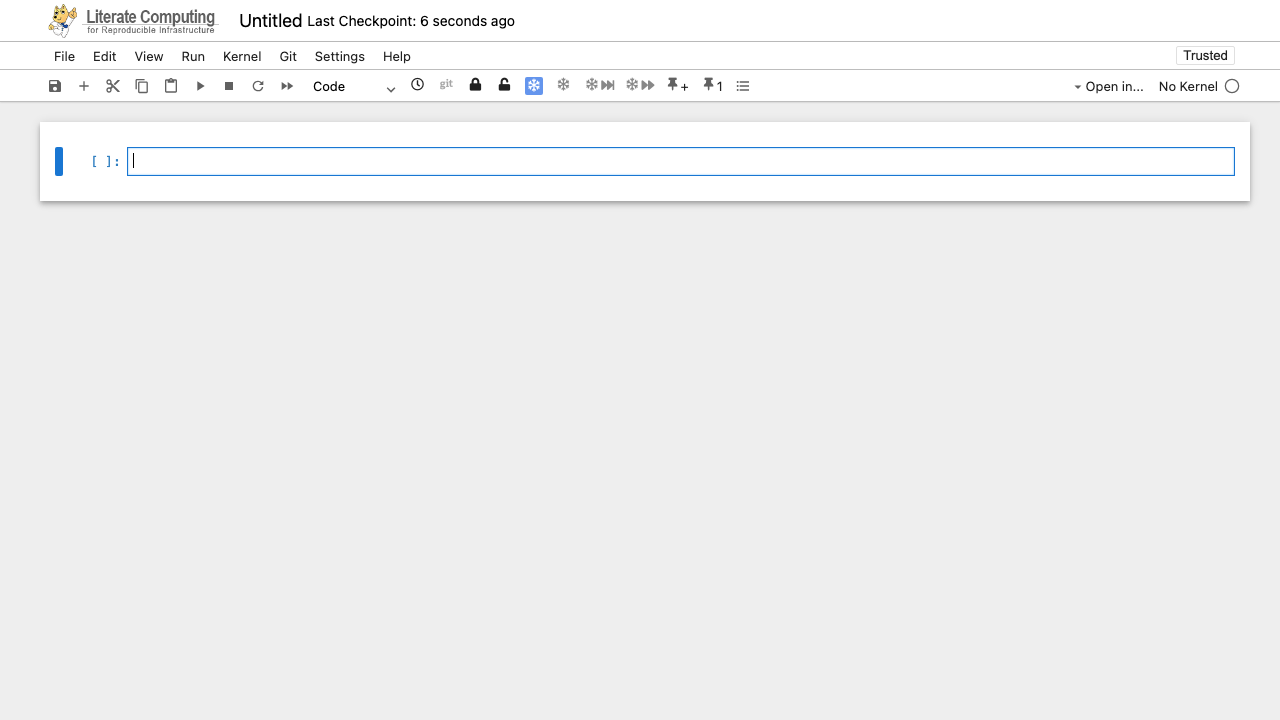

In [7]:
async def _step_create_notebook(page):
    # Create a new notebook using the notebook7 helper
    new_page = await create_new_notebook(page, kernel="Python 3", timeout=transition_timeout)
    print("✓ New notebook created")
    return new_page

await run_pw(_step_create_notebook)

## Rename and save the notebook

Start epoch: 1766558518.812047 seconds


✓ Notebook renamed and saved


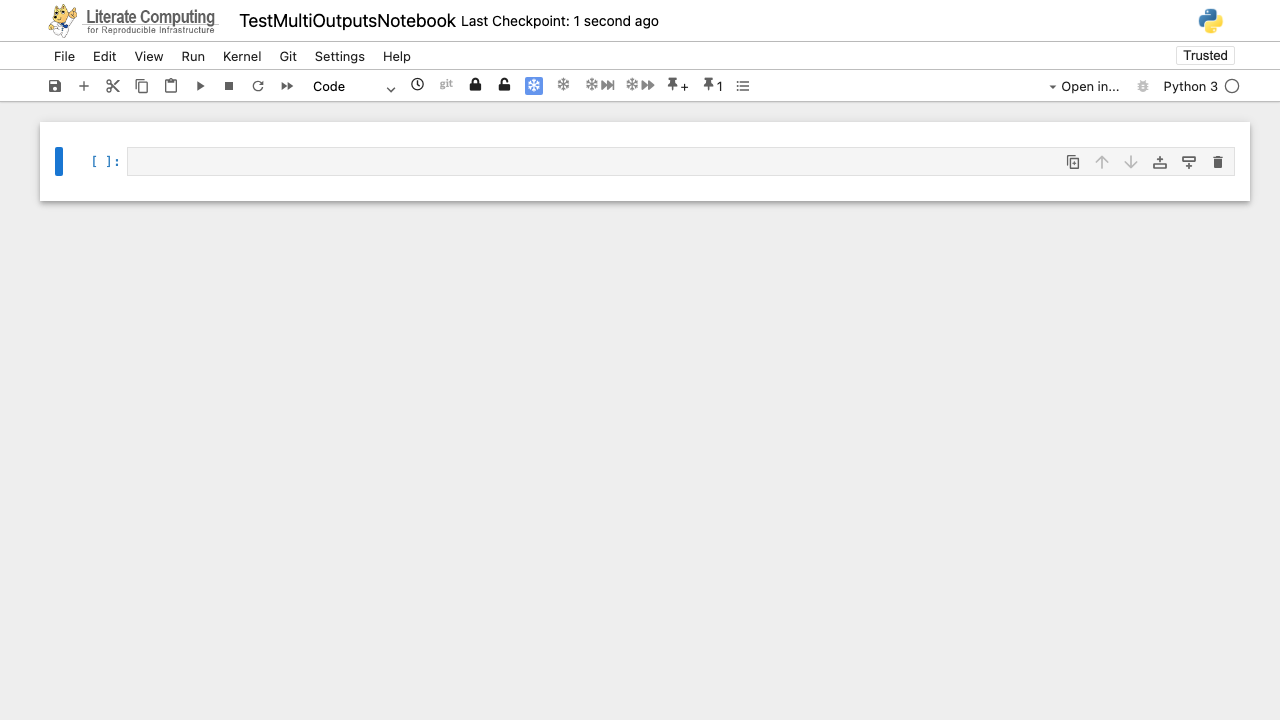

In [8]:
async def _step_rename_and_save(page):
    # Rename the notebook
    await rename_notebook(page, test_filename, timeout=transition_timeout)
    
    # Save the notebook
    await save_notebook(page)
    
    print("✓ Notebook renamed and saved")

await run_pw(_step_rename_and_save)

## Execute a cell with output to trigger multi_outputs

Start epoch: 1766558520.776648 seconds


✓ Cell executed


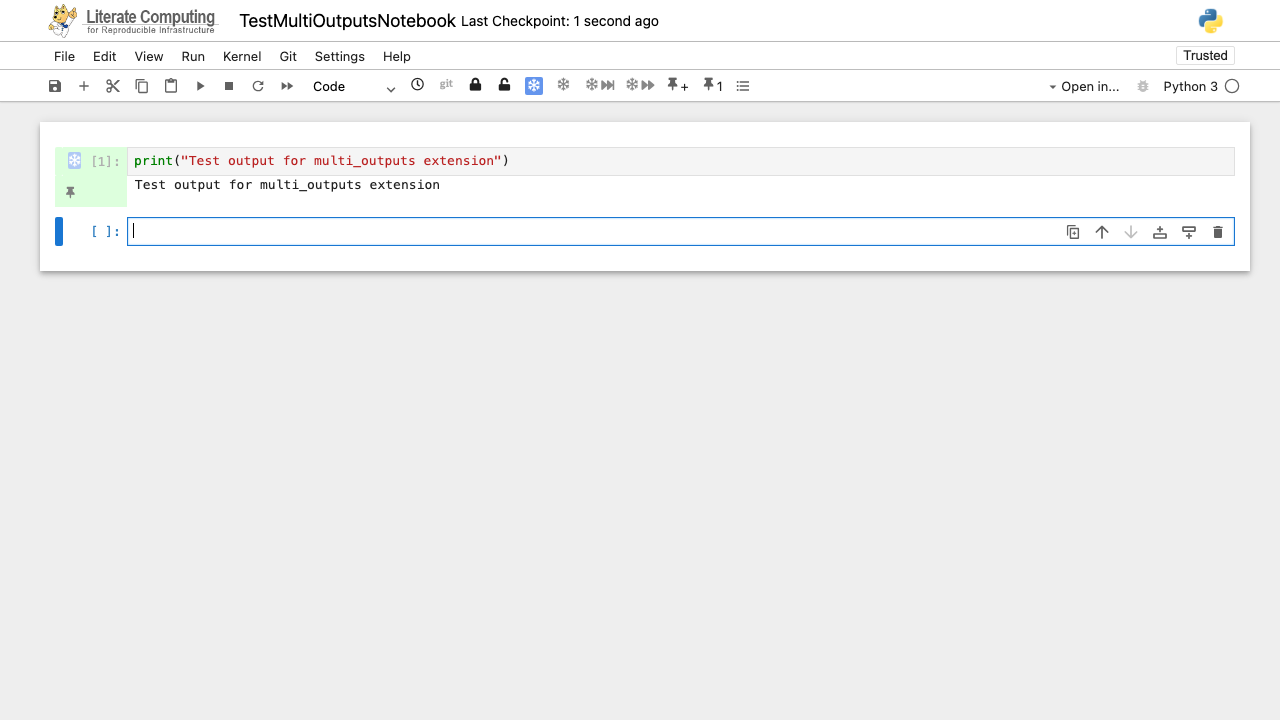

In [9]:
async def _step_execute_cell(page):
    # Use a simple print statement that will show in the output area
    await set_cell(page, 0, "code", 'print("Test output for multi_outputs extension")', timeout=transition_timeout)

    # Execute the cell
    await run_cell(page, 0, True, timeout=transition_timeout)
        
    # Wait a bit for the multi_outputs extension to add its UI elements
    await page.wait_for_timeout(1000)
    
    print("✓ Cell executed")

await run_pw(_step_execute_cell)

## Test multi_outputs basic functionality (pin button and output saving)

Start epoch: 1766558528.222469 seconds


✓ Multi-outputs UI verified (pin button, tabs, and output rendering)


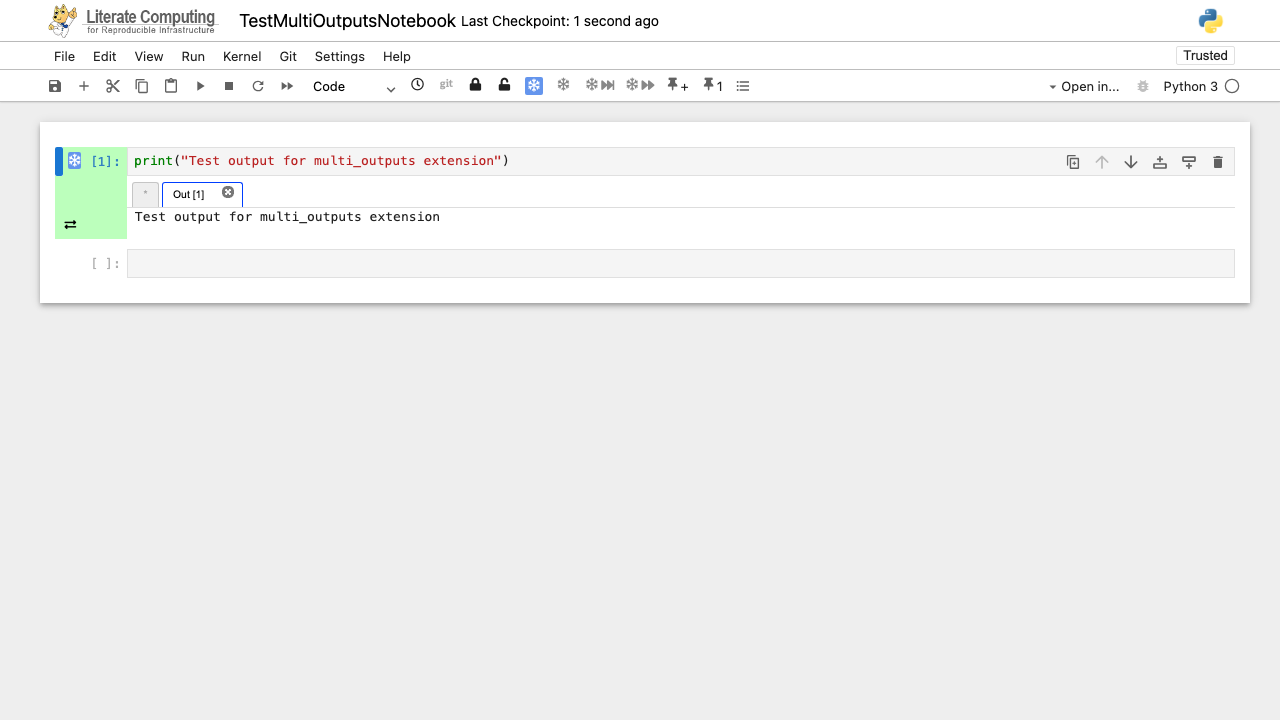

In [10]:
async def _step_verify_multi_outputs(page):
    # Get the first cell
    await select_cell(page, 0, timeout=transition_timeout)
    cell = await get_cell(page, 0, timeout=transition_timeout)
    execution_num = await get_cell_execution_number(page, 0, timeout=transition_timeout)

    # Click pin button on the first cell
    output_ui = cell.locator('.multi-outputs-ui')
    pin_button = output_ui.locator('button')
    await expect(pin_button).to_be_visible(timeout=transition_timeout)
    await pin_button.click()

    # Check that there are tabs
    multi_outputs_widget = cell.locator('.multi-output-widget')
    await expect(multi_outputs_widget).to_be_visible(timeout=transition_timeout)
    multi_output_tabs = multi_outputs_widget.locator('.multi-output-tabs')
    await expect(multi_output_tabs).to_be_visible(timeout=transition_timeout)

    # Check that there are current tab and the first tab
    current_tab = multi_output_tabs.locator('li#tab-output-current')
    await expect(current_tab).to_be_visible(timeout=transition_timeout)
    first_tab = multi_output_tabs.locator(f'li#tab-output-{execution_num}')
    await expect(first_tab).to_be_visible(timeout=transition_timeout)

    # Check that the output is rendered properly
    output_wrapper = multi_outputs_widget.locator(f'.multi-output-wrapper#output-{execution_num}')
    await expect(output_wrapper).to_be_visible(timeout=transition_timeout)
    output_text = await output_wrapper.locator('.jp-RenderedText.jp-OutputArea-output').text_content()
    assert "Test output" in output_text, f"Expected output not found. Got: {output_text}"

    print("✓ Multi-outputs UI verified (pin button, tabs, and output rendering)")


await run_pw(_step_verify_multi_outputs)

## Save the notebook

Start epoch: 1766558528.543661 seconds


✓ Notebook saved


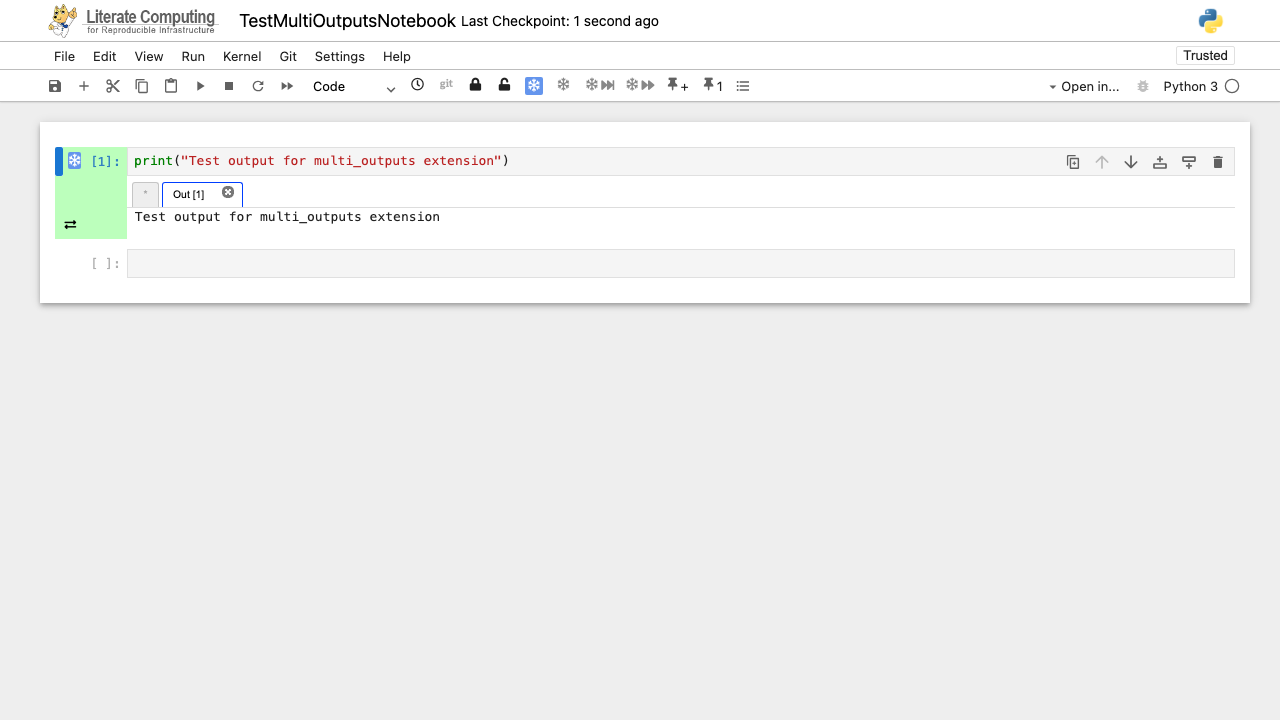

In [11]:
async def _step_save_notebook(page):
    await save_notebook(page)
    print("✓ Notebook saved")

await run_pw(_step_save_notebook)

## Cleanup

In [ ]:
await finish_pw_context()

In [13]:
!rm -rf {work_dir}